## Data loading

Goal: We want to extract ONLY the residential/commercial premises ('RCN_Lokal') 
from the GML file, convert the nested XML structure into a flat Pandas DataFrame
and inspect the data structure to prepare for the Data Cleaning phase.

In [5]:
import pandas as pd
import xml.etree.ElementTree as ET

In [7]:
file_path = '../data\Baza_danych_RCN_Poznan_2021-2025.gml'

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\dudek\AppData\Local\Temp\ipykernel_5856\1120877732.py:1: SyntaxWarning: invalid escape sequence '\B'
  file_path = '../data\Baza_danych_RCN_Poznan_2021-2025.gml'


**Task 1: Load the XML tree and define the dictionary of namespaces we will need.**

1. Use ET.parse() to load the file and get the root element.
2. Define a dictionary named 'namespaces' with 'gml' and 'rcn' prefixes.

In [8]:
# SOLUTION
tree = ET.parse(file_path)
root = tree.getroot()

namespaces = {
    'gml': 'http://www.opengis.net/gml/3.2',
    'rcn': 'urn:gugik:specyfikacje:gmlas:rejestrcennieruchomosci:1.0',
    'xlink': 'http://www.w3.org/1999/xlink' 
}
print(f"Successfully loaded XML. Root tag: {root.tag.split('}')[-1]}")

Successfully loaded XML. Root tag: FeatureCollection


**Task 2: Find all elements matching the 'rcn:RCN_Lokal' tag within the document.**

1. Use root.findall() with the correct XPath and namespaces to find all 'RCN_Lokal' nodes.
2. Count how many premises were found.

In [23]:
# SOLUTION
lokale_nodes = root.findall('.//rcn:RCN_Lokal', namespaces)
print(f"Found {len(lokale_nodes)} premises (lokale) in the dataset.")

Found 65461 premises (lokale) in the dataset.


**Task 3: Flattening the Nested Data**

1. Create an empty list `lokale_data`.
2. Loop through `lokale_nodes`. For each node, loop through its children.
3. Extract the tag name (ignoring the URI namespace) and its text value.
4. Append the created dictionary to the list.

In [24]:
# SOLUTION
lokale_data = []

for node in lokale_nodes:
    lokal_dict = {}
    for child in node:
        tag_name = child.tag.split('}')[-1] 
        
        value = child.text.strip() if child.text and child.text.strip() else None
        if not value and child.attrib:
            value = child.attrib.get(f"{{{namespaces['xlink']}}}href", None)
            
        lokal_dict[tag_name] = value
        
    lokale_data.append(lokal_dict)

print(f"Successfully flattened {len(lokale_data)} records. First record preview:")
print(lokale_data[0] if lokale_data else "No data found.")

Successfully flattened 65461 records. First record preview:
{'boundedBy': None, 'idLokalu': '306401_1.0005.AR_03.84.1_BUD.291_LOK', 'georeferencja': None, 'funkcjaLokalu': '1', 'liczbaIzb': '3', 'nrKondygnacji': '5', 'powUzytkowaLokalu': '61.87', 'cenaLokaluBrutto': '400000.0', 'adresBudynkuZLokalem': None}


**Task 4: Converting it into a tabular format.**

1. Convert the `lokale_data` list into a Pandas DataFrame called `df_lokale`.
2. Display the first 5 rows.

In [25]:
# SOLUTION 
df_lokale = pd.DataFrame(lokale_data)
print("\nDataFrame Head:")
print(df_lokale.head())


DataFrame Head:
  boundedBy                              idLokalu georeferencja funkcjaLokalu  \
0      None  306401_1.0005.AR_03.84.1_BUD.291_LOK          None             1   
1      None  306401_1.0005.AR_03.84.1_BUD.392_LOK          None             6   
2      None  306401_1.0039.AR_32.130.3_BUD.32_LOK          None             1   
3      None  306401_1.0039.AR_32.130.3_BUD.19_LOK          None             1   
4      None  306401_1.0039.AR_32.130.3_BUD.34_LOK          None             1   

  liczbaIzb nrKondygnacji powUzytkowaLokalu cenaLokaluBrutto  \
0         3             5             61.87         400000.0   
1         5            -3          11475.43          50000.0   
2         2             5             48.26         267000.0   
3         3             5             88.91         448995.0   
4         2             1             57.26         300000.0   

   adresBudynkuZLokalem powUzytkowaPomieszczenPrzynal dodatkoweInformacje  \
0                   NaN           

**Task 5: Inspect the data types and check for missing values (NaNs).**

1. Use .info() to check column data types.
2. Use .isnull().sum() to count missing values in each column.

In [26]:
# SOLUTION 
print("\n Data Info")
df_lokale.info() 

print("\n Missing Values Count")
missing_values = df_lokale.isnull().sum()
print(missing_values[missing_values > 0])


 Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65461 entries, 0 to 65460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   boundedBy                      0 non-null      object 
 1   idLokalu                       65461 non-null  object 
 2   georeferencja                  0 non-null      object 
 3   funkcjaLokalu                  65461 non-null  object 
 4   liczbaIzb                      50514 non-null  object 
 5   nrKondygnacji                  62888 non-null  object 
 6   powUzytkowaLokalu              65461 non-null  object 
 7   cenaLokaluBrutto               63401 non-null  object 
 8   adresBudynkuZLokalem           0 non-null      float64
 9   powUzytkowaPomieszczenPrzynal  11247 non-null  object 
 10  dodatkoweInformacje            1080 non-null   object 
 11  kwotaPodatkuVAT                145 non-null    object 
dtypes: float64(1), object(11)
memory u

**Task 6: Categorical Data Profiling**

1. Check the number of unique values in all columns
2. Select a categorical column and display the count of each unique value

In [ ]:
# SOLUTION 
print("Unique values per column:")
print(df_lokale.nunique())

print("\nValue counts for the premise type ('funkcjaLokalu'):")

print(df_lokale['funkcjaLokalu'].value_counts(dropna=False))


--- TASK 8: Categorical Profiling ---
Unique values per column:
boundedBy                            0
idLokalu                         48765
georeferencja                        0
funkcjaLokalu                        6
liczbaIzb                           22
nrKondygnacji                       26
powUzytkowaLokalu                 9757
cenaLokaluBrutto                 28468
adresBudynkuZLokalem                 0
powUzytkowaPomieszczenPrzynal     1396
dodatkoweInformacje                 83
kwotaPodatkuVAT                    107
dtype: int64

Value counts for the premise type ('funkcjaLokalu'):
funkcjaLokalu
1    51109
5    11622
6     1986
2      693
3       43
4        8
Name: count, dtype: int64


---
## Data Cleaning

Goal: Starting from `df_lokale`, we will audit and visualise missing data, cast columns to
their correct types, decode categorical codes, detect outliers, impute missing values using
three different strategies, and engineer derived features.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

**Task 1: Audit missing values visually.**

1. Use `msno.bar()` to plot the proportion of non-null values per column.
2. Use `msno.matrix()` to reveal the row-level nullity pattern.
3. Use `msno.heatmap()` to check whether missingness in one column predicts missingness in another.

C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\410398407.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


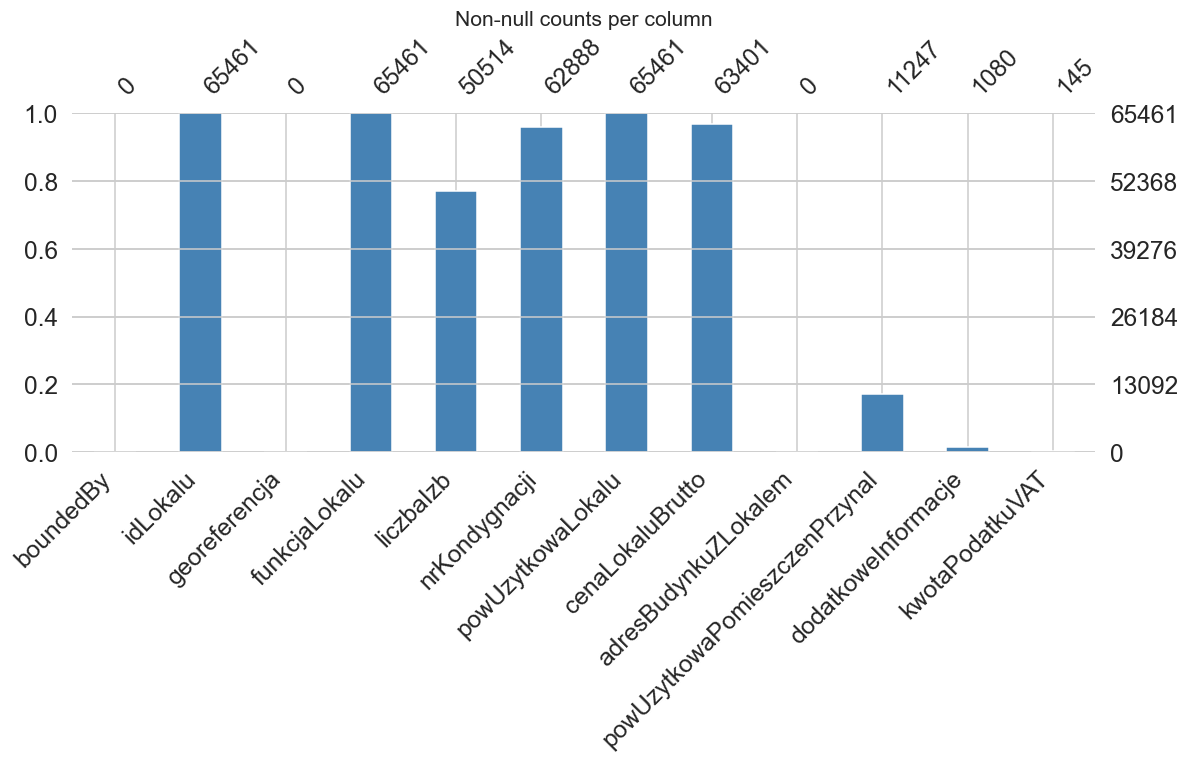

C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\410398407.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


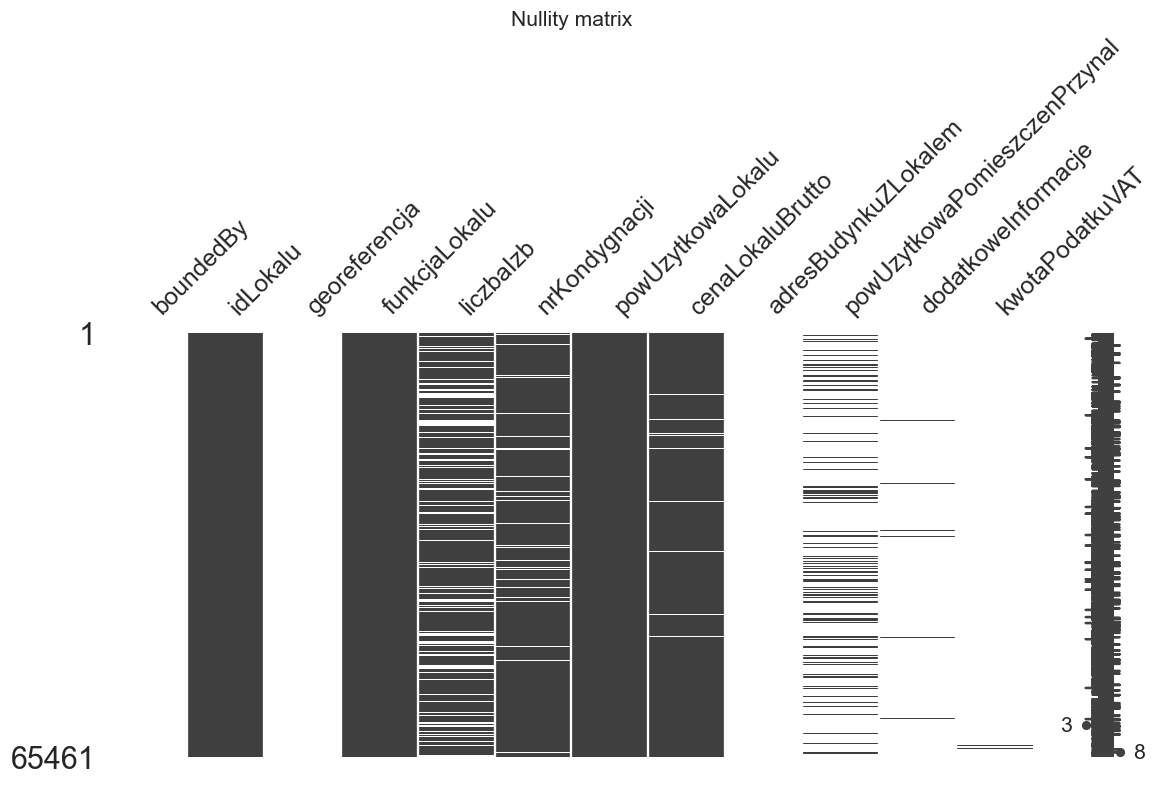

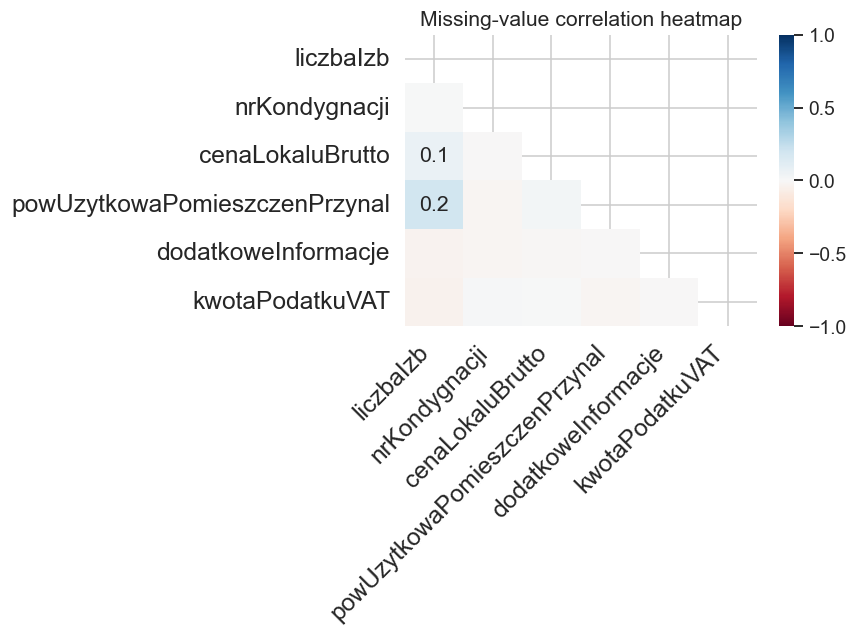

In [32]:
# SOLUTION
msno.bar(df_lokale, figsize=(12, 4), color='steelblue')
plt.title('Non-null counts per column')
plt.tight_layout()
plt.show()

msno.matrix(df_lokale, figsize=(12, 5))
plt.title('Nullity matrix')
plt.tight_layout()
plt.show()

msno.heatmap(df_lokale, figsize=(8, 6))
plt.title('Missing-value correlation heatmap')
plt.tight_layout()
plt.show()

**Task 2: Define the column type configuration and cast all columns.**

1. Define a `COLUMN_TYPES` dictionary mapping each column to its target dtype
   (`'float64'`, `'Int64'`, or `'str'`). This is the single place to adjust types later.
2. Apply the types in a loop: use `pd.to_numeric(..., errors='coerce')` for numeric columns,
   then cast to `'Int64'` where needed.
3. Print dtypes before and after to confirm.

In [33]:
# SOLUTION
COLUMN_TYPES = {
    'powUzytkowaLokalu':             'float64',
    'cenaLokaluBrutto':              'float64',
    'liczbaIzb':                     'Int64',
    'nrKondygnacji':                 'Int64',
    'funkcjaLokalu':                 'Int64',
    'powUzytkowaPomieszczenPrzynal': 'float64',
    'kwotaPodatkuVAT':               'float64',
    'dodatkoweInformacje':           'str',
}

df = df_lokale.copy()

print('Before casting:')
print(df.dtypes[list(COLUMN_TYPES.keys())])

for col, dtype in COLUMN_TYPES.items():
    if col not in df.columns:
        continue
    if dtype in ('float64', 'Int64'):
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if dtype == 'Int64':
            df[col] = df[col].astype('Int64')
    else:
        df[col] = df[col].where(df[col].notna(), other=pd.NA).astype(dtype)

print('\nAfter casting:')
print(df.dtypes[list(COLUMN_TYPES.keys())])

Before casting:
powUzytkowaLokalu                float64
cenaLokaluBrutto                 float64
liczbaIzb                         object
nrKondygnacji                     object
funkcjaLokalu                     object
powUzytkowaPomieszczenPrzynal     object
kwotaPodatkuVAT                   object
dodatkoweInformacje               object
dtype: object

After casting:
powUzytkowaLokalu                float64
cenaLokaluBrutto                 float64
liczbaIzb                          Int64
nrKondygnacji                      Int64
funkcjaLokalu                      Int64
powUzytkowaPomieszczenPrzynal    float64
kwotaPodatkuVAT                  float64
dodatkoweInformacje               object
dtype: object


**Task 3: Decode `funkcjaLokalu` codes into human-readable labels.**

1. Define a `FUNKCJA_LABELS` dictionary mapping integer codes to Polish labels (RCN standard).
2. Create a new column `funkcjaLokalu_label` by mapping the codes.
3. Plot a horizontal bar chart showing the count of premises per type.

C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\3741548902.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='funkcjaLokalu_label', order=order, palette='Blues_r', ax=ax)


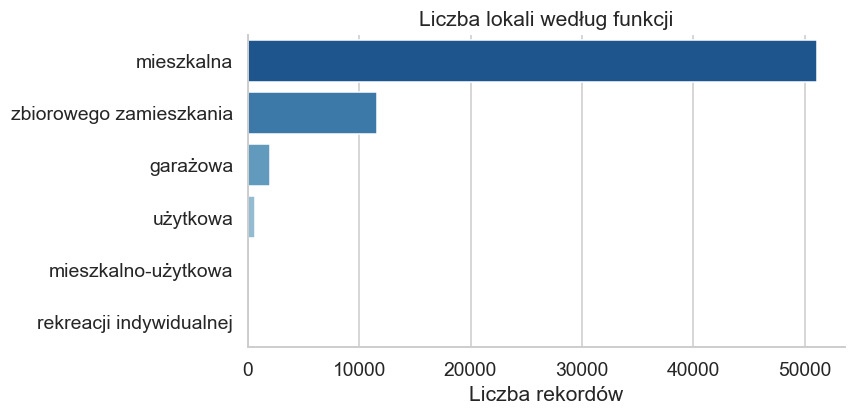

funkcjaLokalu_label
mieszkalna                 51109
zbiorowego zamieszkania    11622
garażowa                    1986
użytkowa                     693
mieszkalno-użytkowa           43
rekreacji indywidualnej        8
Name: count, dtype: int64


In [34]:
# SOLUTION
FUNKCJA_LABELS = {
    1: 'mieszkalna',
    2: 'użytkowa',
    3: 'mieszkalno-użytkowa',
    4: 'rekreacji indywidualnej',
    5: 'zbiorowego zamieszkania',
    6: 'garażowa',
    7: 'inne',
}

df['funkcjaLokalu_label'] = df['funkcjaLokalu'].map(FUNKCJA_LABELS).fillna('nieznana')

fig, ax = plt.subplots(figsize=(8, 4))
order = df['funkcjaLokalu_label'].value_counts().index
sns.countplot(data=df, y='funkcjaLokalu_label', order=order, palette='Blues_r', ax=ax)
ax.set_title('Liczba lokali według funkcji')
ax.set_xlabel('Liczba rekordów')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(df['funkcjaLokalu_label'].value_counts())

**Task 4: Detect and flag outliers in key numeric columns.**

1. Plot box plots for `cenaLokaluBrutto` and `powUzytkowaLokalu` to spot extreme values.
2. Plot a scatter of price vs. area coloured by `funkcjaLokalu_label`.
3. Plot a histogram of `nrKondygnacji` — inspect negative values (basement units).
4. Compute IQR-based bounds (factor 3.0) for price and area; add a boolean `is_outlier` flag.
5. Add a boolean `is_underground` flag where `nrKondygnacji < 0`.

C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\1350615450.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=area_plot, x='funkcjaLokalu_label', y='powUzytkowaLokalu',


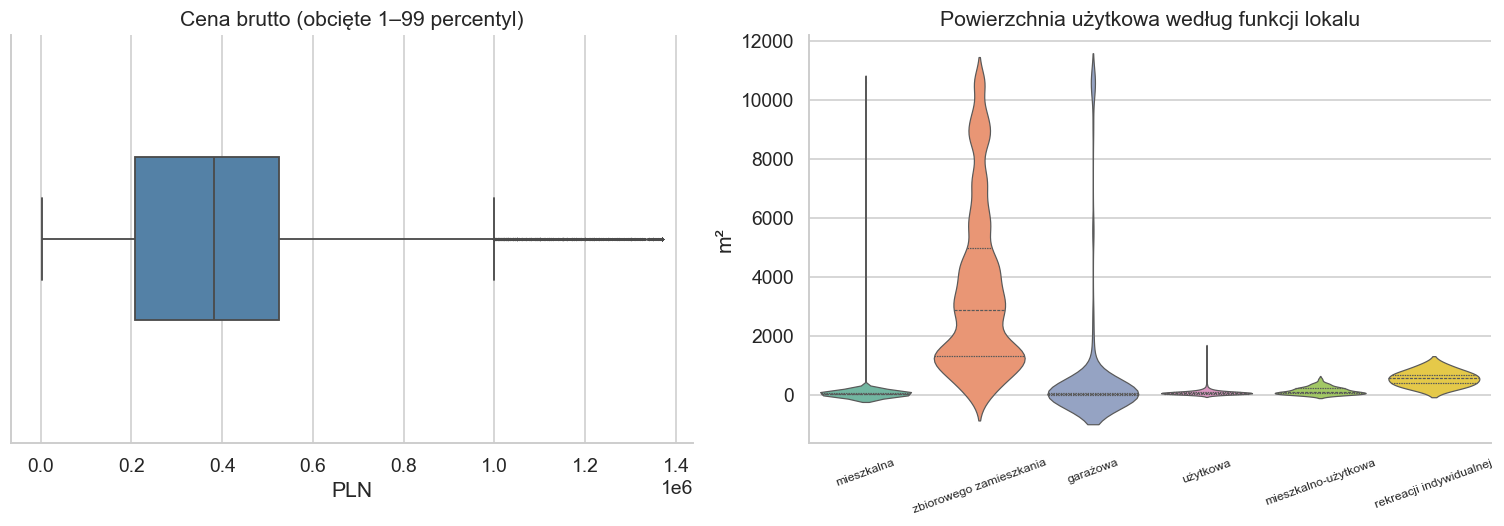

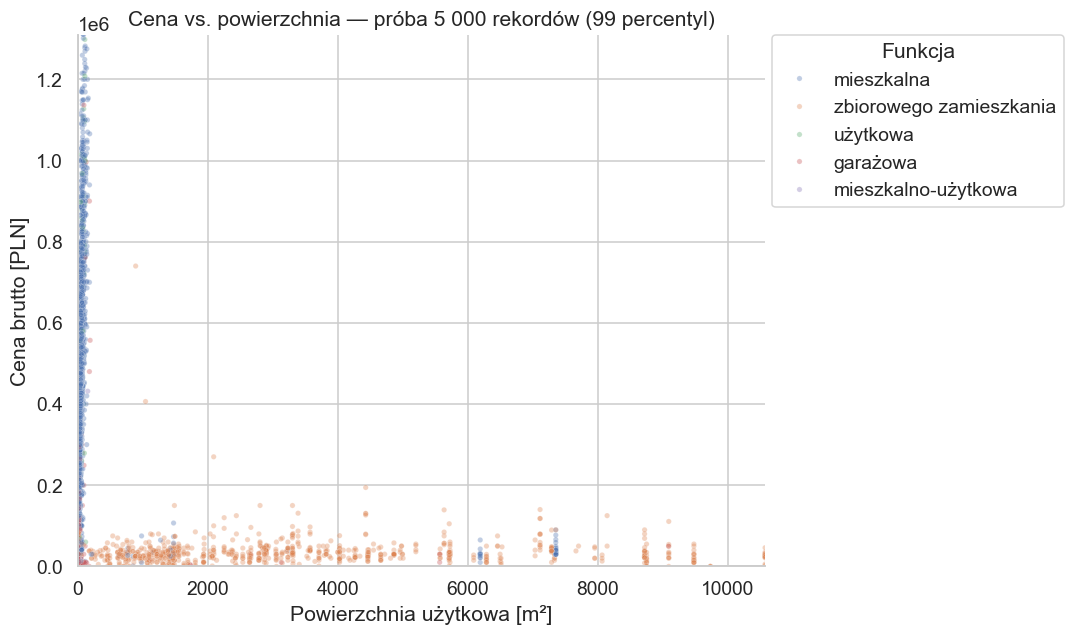

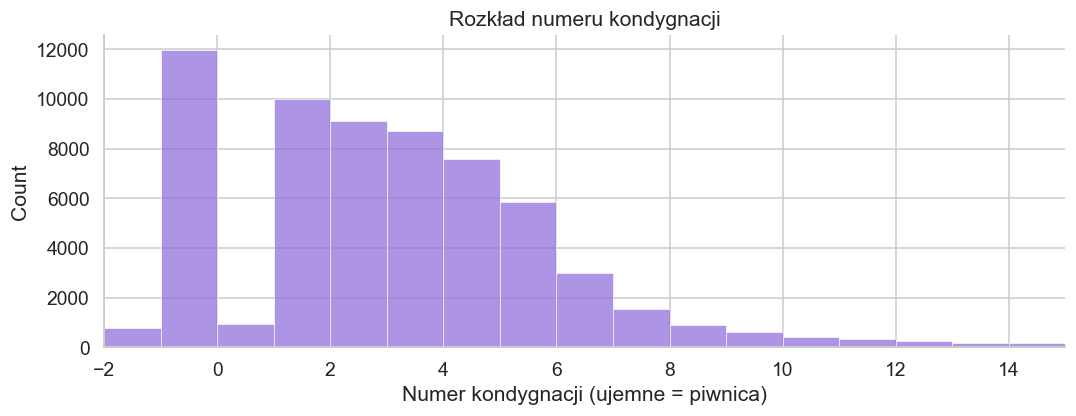

Outlier flags  : 12960 rows (19.8%)
Underground    : 12846 rows


In [35]:
# SOLUTION
NUMERIC_COLS = ['cenaLokaluBrutto', 'powUzytkowaLokalu', 'liczbaIzb',
                'nrKondygnacji', 'powUzytkowaPomieszczenPrzynal']

def clip_series(s, lo=0.01, hi=0.99):
    """Return series clipped at given quantiles, dropping NaN first."""
    s = s.dropna()
    return s.clip(s.quantile(lo), s.quantile(hi))

# — Price boxplot + area violin by premise type —
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=clip_series(df['cenaLokaluBrutto']), ax=axes[0],
            color='steelblue', width=0.4, linewidth=1.2,
            flierprops=dict(marker='.', markersize=2))
axes[0].set_title('Cena brutto (obcięte 1–99 percentyl)')
axes[0].set_xlabel('PLN')

area_plot = df.dropna(subset=['powUzytkowaLokalu']).copy()
lo, hi = area_plot['powUzytkowaLokalu'].quantile(0.01), area_plot['powUzytkowaLokalu'].quantile(0.99)
area_plot['powUzytkowaLokalu'] = area_plot['powUzytkowaLokalu'].clip(lo, hi)
order = area_plot['funkcjaLokalu_label'].value_counts().index
sns.violinplot(data=area_plot, x='funkcjaLokalu_label', y='powUzytkowaLokalu',
               order=order, palette='Set2', ax=axes[1], linewidth=0.8, inner='quartile')
axes[1].set_title('Powierzchnia użytkowa według funkcji lokalu')
axes[1].set_xlabel('')
axes[1].set_ylabel('m²')
axes[1].tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout()
plt.show()

# — Price vs area scatter clipped —
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.dropna(subset=['cenaLokaluBrutto', 'powUzytkowaLokalu']).sample(min(5000, len(df)), random_state=42)
x_hi = sample['powUzytkowaLokalu'].quantile(0.99)
y_hi = sample['cenaLokaluBrutto'].quantile(0.99)
sns.scatterplot(data=sample, x='powUzytkowaLokalu', y='cenaLokaluBrutto',
                hue='funkcjaLokalu_label', alpha=0.35, s=12, ax=ax)
ax.set_xlim(0, x_hi)
ax.set_ylim(0, y_hi)
ax.set_title('Cena vs. powierzchnia — próba 5 000 rekordów (99 percentyl)')
ax.set_xlabel('Powierzchnia użytkowa [m²]')
ax.set_ylabel('Cena brutto [PLN]')
ax.legend(title='Funkcja', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

# — Floor distribution —
fig, ax = plt.subplots(figsize=(10, 4))
floor_data = df['nrKondygnacji'].dropna()
sns.histplot(floor_data, bins=range(int(floor_data.min()), int(floor_data.max()) + 2),
             ax=ax, color='mediumpurple', edgecolor='white', linewidth=0.4)
ax.set_title('Rozkład numeru kondygnacji')
ax.set_xlabel('Numer kondygnacji (ujemne = piwnica)')
ax.set_xlim(floor_data.quantile(0.005), floor_data.quantile(0.995))
plt.tight_layout()
plt.show()

def iqr_bounds(series, factor=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

price_lo, price_hi = iqr_bounds(df['cenaLokaluBrutto'].dropna())
area_lo,  area_hi  = iqr_bounds(df['powUzytkowaLokalu'].dropna())

df['is_outlier'] = (
    (df['cenaLokaluBrutto'] < price_lo) | (df['cenaLokaluBrutto'] > price_hi) |
    (df['powUzytkowaLokalu'] < area_lo)  | (df['powUzytkowaLokalu'] > area_hi)
)
df['is_underground'] = df['nrKondygnacji'].fillna(0) < 0

print(f'Outlier flags  : {df["is_outlier"].sum()} rows ({df["is_outlier"].mean():.1%})')
print(f'Underground    : {df["is_underground"].sum()} rows')

---
## Data Imputation

Three strategies are compared side-by-side, each on an independent copy of `df`:

| Copy | Strategy |
|---|---|
| `df_median` | grouped median per `funkcjaLokalu` |
| `df_pmm` | predictive mean matching |
| `df_stochastic` | stochastic regression |

**Columns imputed:** `cenaLokaluBrutto`, `liczbaIzb`, `nrKondygnacji`, `powUzytkowaPomieszczenPrzynal`  
**Predictors used:** `powUzytkowaLokalu`, `funkcjaLokalu` (both fully observed)

In [36]:
# Configuration — adjust target and predictor columns here
IMPUTE_COLS    = ['cenaLokaluBrutto', 'liczbaIzb', 'nrKondygnacji', 'powUzytkowaPomieszczenPrzynal']
PREDICTOR_COLS = ['powUzytkowaLokalu', 'funkcjaLokalu']

**Task 1: Method A — Median Imputation.**

1. Copy `df` into `df_median`.
2. For each column in `IMPUTE_COLS`, fill missing values with the **median of the group**
   defined by `funkcjaLokalu`.
3. Overlay original vs. imputed distribution for `cenaLokaluBrutto` using `sns.histplot`.

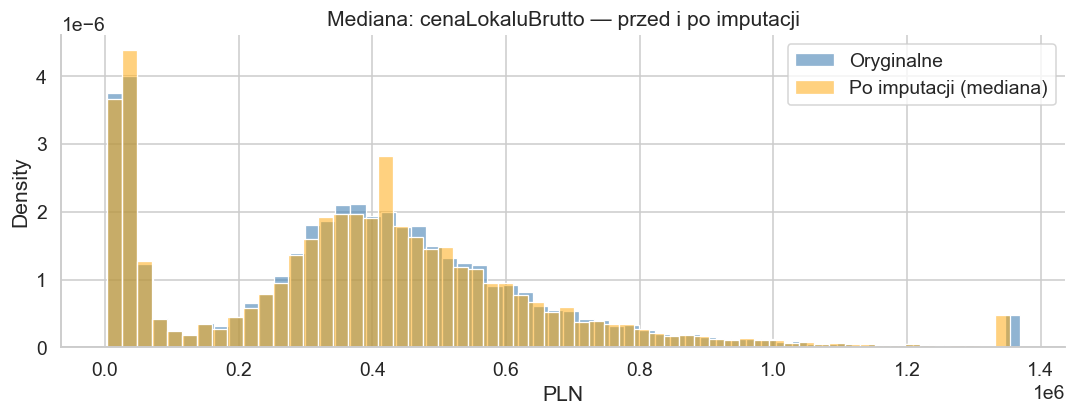

Missing after median imputation: {'cenaLokaluBrutto': 0, 'liczbaIzb': 8, 'nrKondygnacji': 0, 'powUzytkowaPomieszczenPrzynal': 0}


In [37]:
# SOLUTION
df_median = df.copy()

for col in IMPUTE_COLS:
    group_median = df_median.groupby('funkcjaLokalu')[col].transform('median')
    df_median[col] = df_median[col].fillna(group_median)

fig, ax = plt.subplots(figsize=(10, 4))
s_orig = clip_series(df['cenaLokaluBrutto'])
s_imp  = clip_series(df_median['cenaLokaluBrutto'])
sns.histplot(s_orig, color='steelblue', label='Oryginalne', stat='density', bins=60, ax=ax, alpha=0.6)
sns.histplot(s_imp,  color='orange',    label='Po imputacji (mediana)', stat='density', bins=60, ax=ax, alpha=0.5)
ax.set_title('Mediana: cenaLokaluBrutto — przed i po imputacji')
ax.set_xlabel('PLN')
ax.legend()
plt.tight_layout()
plt.show()

print('Missing after median imputation:', df_median[IMPUTE_COLS].isnull().sum().to_dict())

**Task 2: Method B — Predictive Mean Matching (PMM).**

1. Implement `pmm_impute(df, target_col, predictors, k=5)`:
   - Fit OLS on observed rows using `predictors`.
   - For each missing row compute its predicted value.
   - Replace the missing value with a randomly chosen observed value from the `k` closest
     predicted values — the **donor pool**. This preserves real observed values and avoids
     impossible imputed values.
2. Apply `pmm_impute` to each column in `IMPUTE_COLS` on a copy `df_pmm`.
3. Overlay a KDE of original vs. PMM-imputed `cenaLokaluBrutto`.

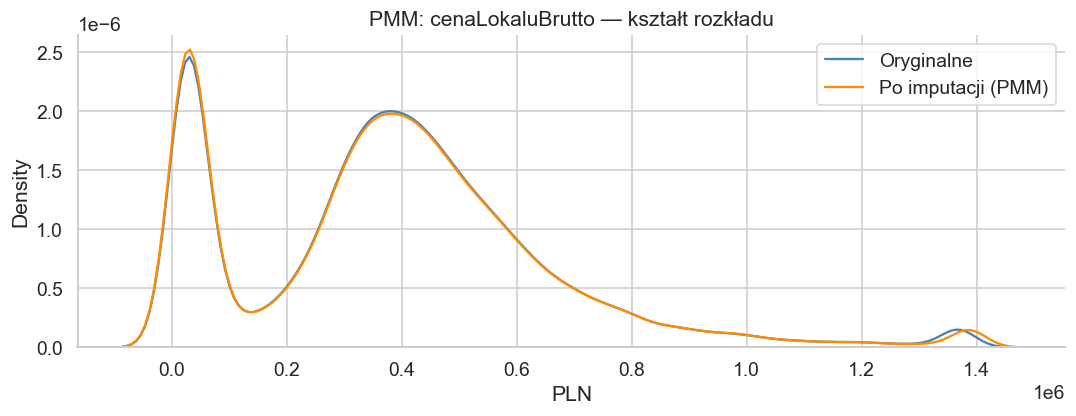

Missing after PMM: {'cenaLokaluBrutto': 0, 'liczbaIzb': 0, 'nrKondygnacji': 0, 'powUzytkowaPomieszczenPrzynal': 0}


In [38]:
# SOLUTION
def pmm_impute(df, target_col, predictors, k=5, random_state=42):
    rng   = np.random.default_rng(random_state)
    df    = df.copy()
    preds = [p for p in predictors if p != target_col and p in df.columns]

    mask_obs  = df[target_col].notna() & df[preds].notna().all(axis=1)
    mask_miss = df[target_col].isna()  & df[preds].notna().all(axis=1)
    if mask_obs.sum() == 0 or mask_miss.sum() == 0:
        return df

    X_obs  = df.loc[mask_obs,  preds].values.astype(float)
    y_obs  = df.loc[mask_obs,  target_col].values.astype(float)
    X_miss = df.loc[mask_miss, preds].values.astype(float)

    X_obs_a  = np.column_stack([np.ones(len(X_obs)),  X_obs])
    X_miss_a = np.column_stack([np.ones(len(X_miss)), X_miss])

    beta       = np.linalg.lstsq(X_obs_a, y_obs, rcond=None)[0]
    y_hat_obs  = X_obs_a  @ beta
    y_hat_miss = X_miss_a @ beta

    donors  = [y_obs[np.argsort(np.abs(y_hat_obs - p))[:k]] for p in y_hat_miss]
    imputed = np.array([rng.choice(d) for d in donors])
    df.loc[mask_miss, target_col] = imputed
    return df

df_pmm = df.copy()
for col in IMPUTE_COLS:
    df_pmm = pmm_impute(df_pmm, col, PREDICTOR_COLS)

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(clip_series(df['cenaLokaluBrutto']),     label='Oryginalne',          color='steelblue', ax=ax)
sns.kdeplot(clip_series(df_pmm['cenaLokaluBrutto']), label='Po imputacji (PMM)',   color='darkorange', ax=ax)
ax.set_title('PMM: cenaLokaluBrutto — kształt rozkładu')
ax.set_xlabel('PLN')
ax.legend()
plt.tight_layout()
plt.show()

print('Missing after PMM:', df_pmm[IMPUTE_COLS].isnull().sum().to_dict())

**Task 3: Method C — Stochastic Regression Imputation.**

1. Implement `stochastic_regression_impute(df, target_col, predictors)`:
   - Fit OLS on observed rows.
   - Predict values for missing rows.
   - Add a random draw from `N(0, σ_residual)` to each predicted value —
     this restores the variance that plain regression imputation removes.
2. Apply to each column in `IMPUTE_COLS` on a copy `df_stochastic`.
3. Overlay a KDE of original vs. stochastic-imputed `cenaLokaluBrutto`.

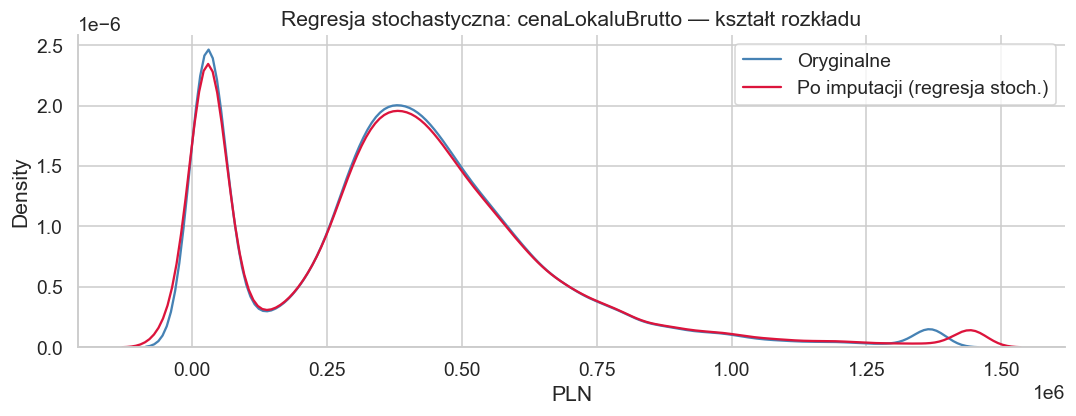

Missing after stochastic regression: {'cenaLokaluBrutto': 0, 'liczbaIzb': 0, 'nrKondygnacji': 0, 'powUzytkowaPomieszczenPrzynal': 0}


In [39]:
# SOLUTION
def stochastic_regression_impute(df, target_col, predictors, random_state=42):
    rng   = np.random.default_rng(random_state)
    df    = df.copy()
    preds = [p for p in predictors if p != target_col and p in df.columns]

    mask_obs  = df[target_col].notna() & df[preds].notna().all(axis=1)
    mask_miss = df[target_col].isna()  & df[preds].notna().all(axis=1)
    if mask_obs.sum() == 0 or mask_miss.sum() == 0:
        return df

    X_obs  = df.loc[mask_obs,  preds].values.astype(float)
    y_obs  = df.loc[mask_obs,  target_col].values.astype(float)
    X_miss = df.loc[mask_miss, preds].values.astype(float)

    X_obs_a  = np.column_stack([np.ones(len(X_obs)),  X_obs])
    X_miss_a = np.column_stack([np.ones(len(X_miss)), X_miss])

    beta      = np.linalg.lstsq(X_obs_a, y_obs, rcond=None)[0]
    residuals = y_obs - X_obs_a @ beta
    sigma     = np.std(residuals)

    y_pred = X_miss_a @ beta + rng.normal(0, sigma, size=len(X_miss))

    # round to integer for Int64 columns before assignment
    if pd.api.types.is_integer_dtype(df[target_col]):
        y_pred = np.round(y_pred).astype(float)

    df.loc[mask_miss, target_col] = y_pred
    return df

df_stochastic = df.copy()
for col in IMPUTE_COLS:
    df_stochastic = stochastic_regression_impute(df_stochastic, col, PREDICTOR_COLS)

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(clip_series(df['cenaLokaluBrutto']),            label='Oryginalne',                      color='steelblue', ax=ax)
sns.kdeplot(clip_series(df_stochastic['cenaLokaluBrutto']), label='Po imputacji (regresja stoch.)',   color='crimson',   ax=ax)
ax.set_title('Regresja stochastyczna: cenaLokaluBrutto — kształt rozkładu')
ax.set_xlabel('PLN')
ax.legend()
plt.tight_layout()
plt.show()

print('Missing after stochastic regression:', df_stochastic[IMPUTE_COLS].isnull().sum().to_dict())

**Task 4: Compare the three imputation methods visually.**

1. Concatenate `df_median`, `df_pmm`, and `df_stochastic` into a long-format DataFrame
   with a `metoda` column.
2. Plot side-by-side box plots for `cenaLokaluBrutto` and `powUzytkowaPomieszczenPrzynal`.
3. Interpret: which method preserves variance best? Which is safest for the target variable?

C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\105382152.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='metoda', y=col, palette='Set2', ax=ax,
C:\Users\dudek\AppData\Local\Temp\ipykernel_7460\105382152.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='metoda', y=col, palette='Set2', ax=ax,


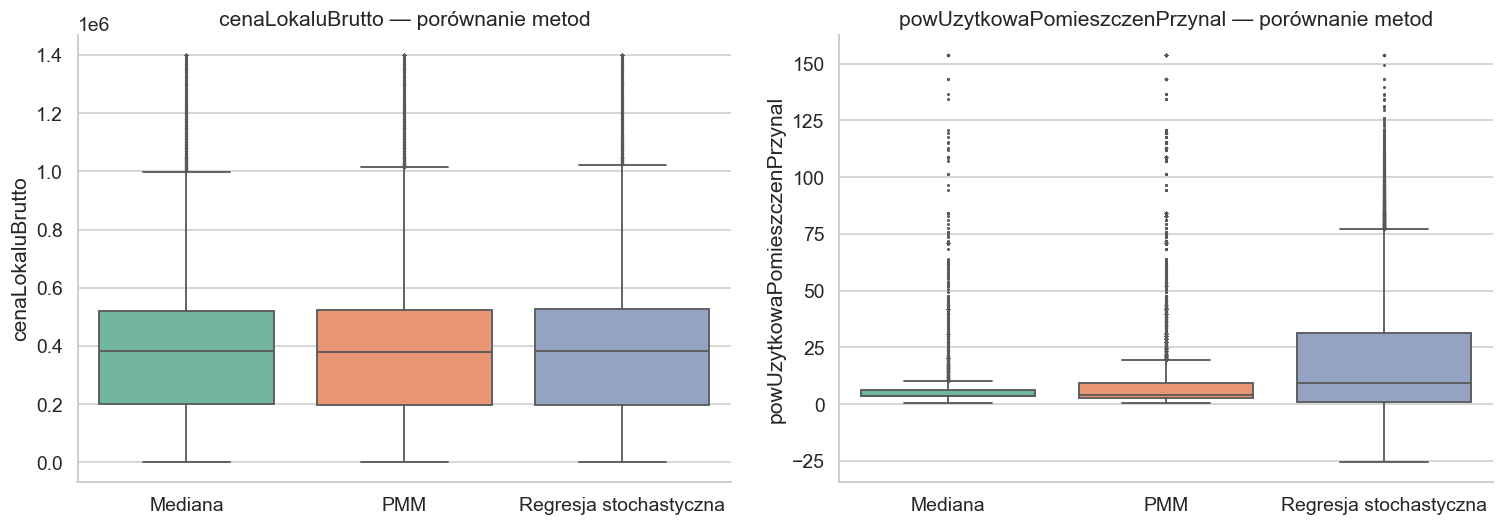

                       cenaLokaluBrutto                                    \
                                  count       mean        std         min   
metoda                                                                      
Mediana                         65461.0  391242.41  701202.97        1.00   
PMM                             65461.0  393327.20  703947.00        1.00   
Regresja stochastyczna          65461.0  391593.56  711761.59 -2195010.83   

                                                                     \
                             25%        50%        75%          max   
metoda                                                                
Mediana                 200000.0  384000.00  519804.06  157300021.0   
PMM                     198598.0  380070.83  524800.00  157300021.0   
Regresja stochastyczna  198100.0  381000.00  528275.50  157300021.0   

                       powUzytkowaPomieszczenPrzynal                       \
                                 

In [40]:
# SOLUTION
compare = pd.concat([
    df_median[IMPUTE_COLS].assign(metoda='Mediana'),
    df_pmm[IMPUTE_COLS].assign(metoda='PMM'),
    df_stochastic[IMPUTE_COLS].assign(metoda='Regresja stochastyczna'),
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['cenaLokaluBrutto', 'powUzytkowaPomieszczenPrzynal']):
    lo = compare[col].quantile(0.01)
    hi = compare[col].quantile(0.99)
    plot_data = compare.copy()
    plot_data[col] = plot_data[col].clip(lo, hi)
    sns.boxplot(data=plot_data, x='metoda', y=col, palette='Set2', ax=ax,
                linewidth=1.2, flierprops=dict(marker='.', markersize=2))
    ax.set_title(f'{col} — porównanie metod')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print(compare.groupby('metoda')[['cenaLokaluBrutto', 'powUzytkowaPomieszczenPrzynal']].describe().round(2))

**Task 5: Final inspection and export.**

1. Run `df_clean.info()` and `df_clean.describe()` for a final sanity check.
2. Plot `msno.bar(df_clean)` to confirm no unexpected nulls remain in key columns.
3. Export each imputed variant to CSV in the `../data/` folder.

In [41]:
# SOLUTION
print('=== Final DataFrame Info ===')
df_clean.info()

print('\n=== Descriptive Statistics ===')
display(df_clean.describe(include='all').T)

msno.bar(df_clean, figsize=(12, 4), color='seagreen')
plt.title('Null counts after cleaning (df_clean / mediana)')
plt.tight_layout()
plt.show()

df_median.to_csv('../data/lokale_median.csv', index=False)
df_pmm.to_csv('../data/lokale_pmm.csv', index=False)
df_stochastic.to_csv('../data/lokale_stochastic.csv', index=False)
df_clean.to_csv('../data/lokale_clean.csv', index=False)

print('Saved: lokale_median.csv, lokale_pmm.csv, lokale_stochastic.csv, lokale_clean.csv')

=== Final DataFrame Info ===


NameError: name 'df_clean' is not defined